## 1. Data (preparing and loading)

In ML, data can be almost anything.
* Excel spreadsheet
* Images of any kind
* Videos (YT has lots of video data)
* Audios like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Buil a model to learn patterns in that numerical 

To showcase this, let's create some *known* data using the linear regression formula

To showcase this, let's create some known data using the linear regression formula.
We'll use a linear regression formula to make a straight line with *known* **parameters**

In [57]:
import torch

# Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim= 1)
y = weight * X + bias

print(X[:10], y[:10]) 
print(len(X), len(y))

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
50 50


### Splitting data into Training and Testing 

In [58]:
# Create a train-test split
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(len(X_train), len(y_train), len(X_test), len(y_test))

40 40 10 10


How might we better visualize our data?

In [59]:
import matplotlib.pyplot as plt

def plot_predictions(train_data=X_train, train_labels=y_train, 
                     test_data=X_test, test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    # Are there predictions?
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14});

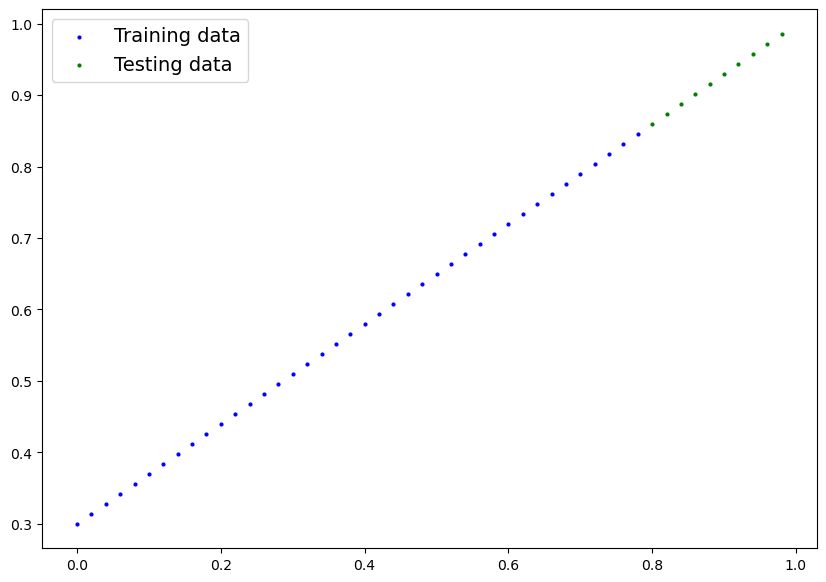

In [60]:
plot_predictions();

## 2. Build Model
Our first PyTorch model!
nn.module: https://docs.pytorch.org/docs/2.12/generated/torch.nn.Module.html

What our model does:
* Start with random values
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w?si=qzd2-raJCLzjcoE8
2. Backpropogation - https://youtu.be/Ilg3gGewQ5U?si=rEmxYY2i-mvx-IZy

In [61]:
from torch import nn
# Create Linear regression model class

class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherits from nn.module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, 
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
        
        # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return  self.weights * x + self.bias # this is the linear regression equation

### PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph).
* Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us.
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward().
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent.
* def forward() - All nn.Module subclasses require you to overwrite forward(). This method defines what happens in the forward computation

See more of these essential modules via the PyTorch cheatsheet - https://pytorch-cn.com/tutorials/beginner/ptcheat.html


### Checking the contents of our PyTorch model

Now we've created a model, let's she what is inside...
So we can check our model parameters or what's inside our model using `.parameters()`

In [62]:
# Create a random seed
torch.manual_seed(42)

#Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [63]:
# List named parameters
print(model_0.state_dict())

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


### Making predictions using `torch.inference_mode()`

To check the model's predictive power, let's see how well it predicts 'y_test' based on 'X_test'.

When we pass data through our model, it's going to run it through the forward method.

More on inference mode: https://x.com/PyTorch/status/1437838231505096708?lang=en

In [64]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

print(y_preds)
print(y_test)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])
tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


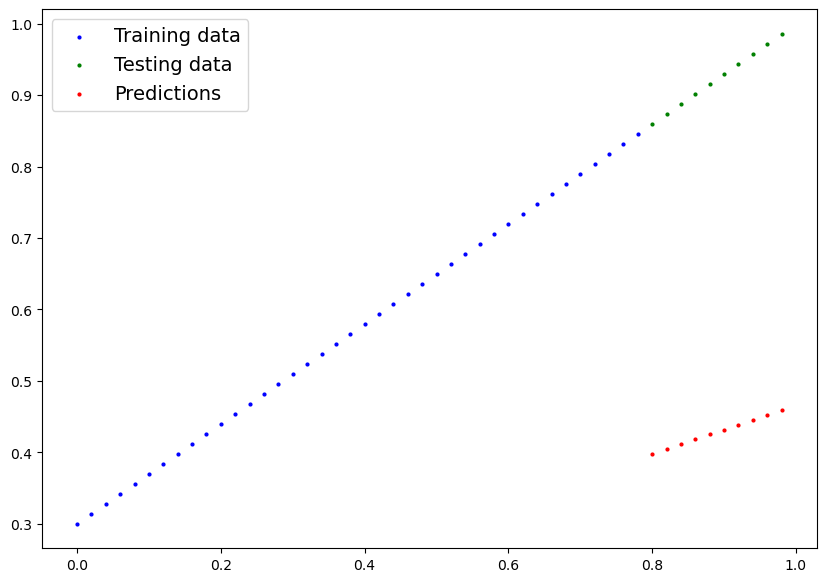

In [65]:
plot_predictions(predictions=y_preds)

### 3. Train Model

The whole idea of training is to move from some *unknown* parameters (these may be random) to some known parameters.
Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor our model's predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. 


Thing we need to train:
* **Loss Function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's paramters (e.g. Weight & Bias in our case) to improve the loss function.

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [66]:
print(model_0.parameters())
print(model_0.state_dict())

<generator object Module.parameters at 0x000002D058172260>
OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])
